In [1]:
#data wrangling
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#statistics
from scipy import stats

#display plots inside notebook
%matplotlib inline

In [3]:
df = pd.read_csv("../data amazon uk/amazon_uk_price.csv")

### Part 1: Analyzing Best-Seller Trends Across Product Categories
#### Objective: Understand the relationship between product categories and their best-seller status.

Crosstab Analysis:
- Create a crosstab between the product category and the isBestSeller status.
- Are there categories where being a best-seller is more prevalent?
Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

Statistical Tests:
- Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
- Compute Cramér's V to understand the strength of association between best-seller status and category.

Visualizations:
- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
#crosstab analysis
crosstab_category_bestseller = pd.crosstab(df["category"], df["isBestSeller"])
crosstab_category_bestseller

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [15]:
best_seller_proportion = (crosstab_category_bestseller[True] / crosstab_category_bestseller.sum(axis=1))
best_seller_proportion = best_seller_proportion.sort_values(ascending=False)
best_seller_proportion.head(10)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Mirrors                           0.028000
Wind Instruments                  0.028000
dtype: float64

The series shows that grocery has the highest proportion of best sellers (5.81%) followed by Smart Home Security & Lighting (5.76%) and Health & Personal Care (5.76%). This suggests that products within these categories are more likely to become best sellers.

#statistical test
H0 = There is no association between product category and best-seller status.
H1 = There is an association between product category and best-seller status.

p < 0.05

The Chi-square test produced a p-value smaller than 0.05 meaning that H0 can be rejected and H1 accepted. Therefore, there is a statistically significant relationship between a product's category and whether it is a best-seller.

In [17]:
stats.chi2_contingency(crosstab_category_bestseller)

Chi2ContingencyResult(statistic=np.float64(36540.20270061387), pvalue=np.float64(0.0), dof=295, expected_freq=array([[2.47190130e+02, 8.09870149e-01],
       [4.05371878e+03, 1.32812173e+01],
       [2.49183599e+02, 8.16401360e-01],
       [1.69145827e+03, 5.54173243e+00],
       [2.53170536e+02, 8.29463782e-01],
       [8.50214439e+03, 2.78556144e+01],
       [1.06650580e+02, 3.49419782e-01],
       [2.57157474e+02, 8.42526204e-01],
       [9.51781673e+03, 3.11832664e+01],
       [1.50008526e+04, 4.91473619e+01],
       [9.32544700e+03, 3.05530045e+01],
       [2.38219520e+02, 7.80479700e-01],
       [3.22941944e+03, 1.05805616e+01],
       [9.44704859e+03, 3.09514084e+01],
       [6.68808779e+03, 2.19122125e+01],
       [5.26275760e+02, 1.72423967e+00],
       [1.90296531e+04, 6.23469391e+01],
       [2.77191835e+03, 9.08164873e+00],
       [2.53170536e+02, 8.29463782e-01],
       [4.04674164e+02, 1.32583581e+00],
       [1.92489346e+04, 6.30653723e+01],
       [3.10482764e+03, 1.017

In [18]:
stats.contingency.association(crosstab_category_bestseller, method = "cramer")

0.1222829439760564

The cramer test produced a value of 0.12, meaning that the association between product's category and best-seller status is weak.

In [27]:
#visualization
top10_bestseller = best_seller_proportion.head(10).index
crosstab_top10 = crosstab_category_bestseller.loc[top10_bestseller]

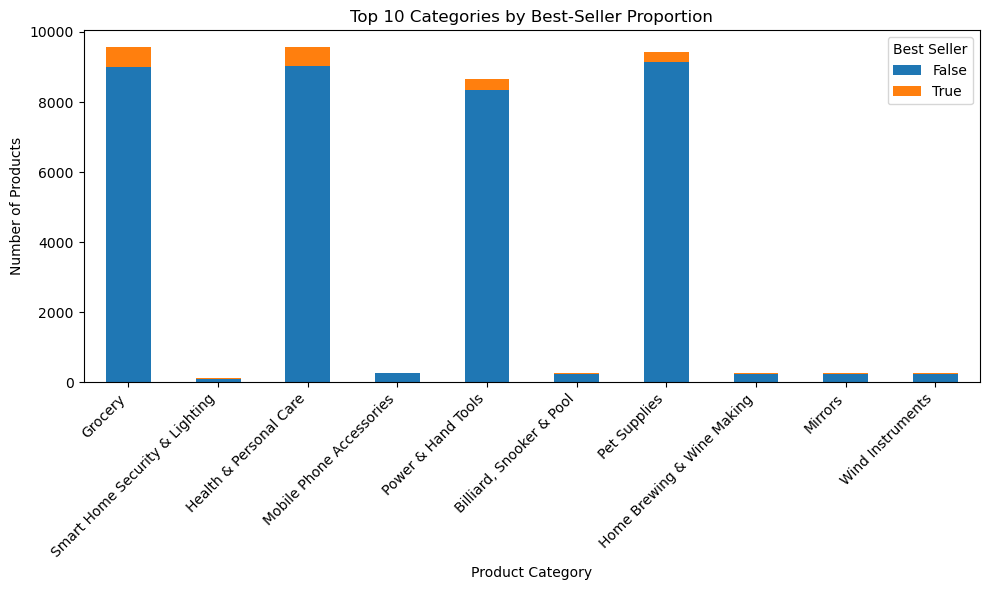

In [28]:
crosstab_top10.plot(
    kind = "bar", 
    stacked = True,
    figsize=(10, 6)
)

plt.title("Top 10 Categories by Best-Seller Proportion")
plt.xlabel("Product Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Best Seller")
plt.tight_layout()
plt.show()

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands
#### Objective: Investigate how different product categories influence product prices.

Preliminary Step: Remove outliers in product prices.
- For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

Violin Plots:
- Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
- Which product category tends to have the highest median price? Don't filter here by top categories.

Bar Charts:
- Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
- Which product category commands the highest average price? Don't filter here by top categories.

Box Plots:
- Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
- Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [30]:
#removing outliers
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1
iqr

np.float64(36.0)

In [32]:
lower_limit = q1 - (1.5 * iqr)
upper_limit = q3 + (1.5 * iqr)
print (lower_limit)
print (upper_limit)

-44.01
99.99000000000001


In [33]:
df_no_outliers = df[(
    df["price"] >= lower_limit) &
    (df["price"] <= upper_limit)]

In [35]:
df.shape

(2443651, 9)

In [37]:
df_no_outliers.shape

(2115963, 9)

In [42]:
#violin plots
top20_categories = df["category"].value_counts().head(20).index
top20_categories

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances', 'Handmade Gifts',
       'Handmade Home Décor', 'Luggage and travel gear', 'Handmade Jewellery',
       'Handmade Artwork', 'Women', 'Handmade Home & Kitchen Products',
       'Handmade Kitchen & Dining', 'Men', 'Baby'],
      dtype='object', name='category')

In [45]:
df_top20 = df_no_outliers[df_no_outliers["category"].isin(top20_categories)]
df_top20

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
19513,21072,B09477KHQ3,"Personalised Birthday Print Gift ""THE YEAR YOU...",4.5,763,7.99,False,900,Handmade Home & Kitchen Products
19514,21073,B0BSRFQYG8,Wax Melts 4 Bars | Build Your Own Box (Choose ...,3.9,117,6.49,True,800,Handmade Home & Kitchen Products
19515,21074,B09N9GVHV9,"Personalised Birthday Print Gift ""ON THE DAY/Y...",4.6,1155,8.99,True,600,Handmade Home & Kitchen Products
19516,21075,B0BRYGV7PQ,Fresh Wax Melts - Laundry Type Wax Melts - Str...,4.5,56,4.99,True,500,Handmade Home & Kitchen Products
19517,21076,B0B1JHB28R,Manta Makes Work Leaving Gifts | I Used to Wor...,4.7,261,9.95,True,400,Handmade Home & Kitchen Products
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


In [46]:
df_top20["category"].value_counts()

category
Sports & Outdoors                         694092
Beauty                                     19233
Bath & Body                                19050
Manicure & Pedicure Products               18904
Handmade Clothing, Shoes & Accessories     18811
Make-up                                    18718
Skin Care                                  18686
Hair Care                                  18625
Birthday Gifts                             18398
Handmade Gifts                             17948
Handmade Home Décor                        17675
Luggage and travel gear                    17557
Women                                      17476
Fragrances                                 17431
Handmade Kitchen & Dining                  17346
Handmade Artwork                           17269
Handmade Home & Kitchen Products           17175
Handmade Jewellery                         17135
Men                                        16596
Baby                                       14883
Name: count

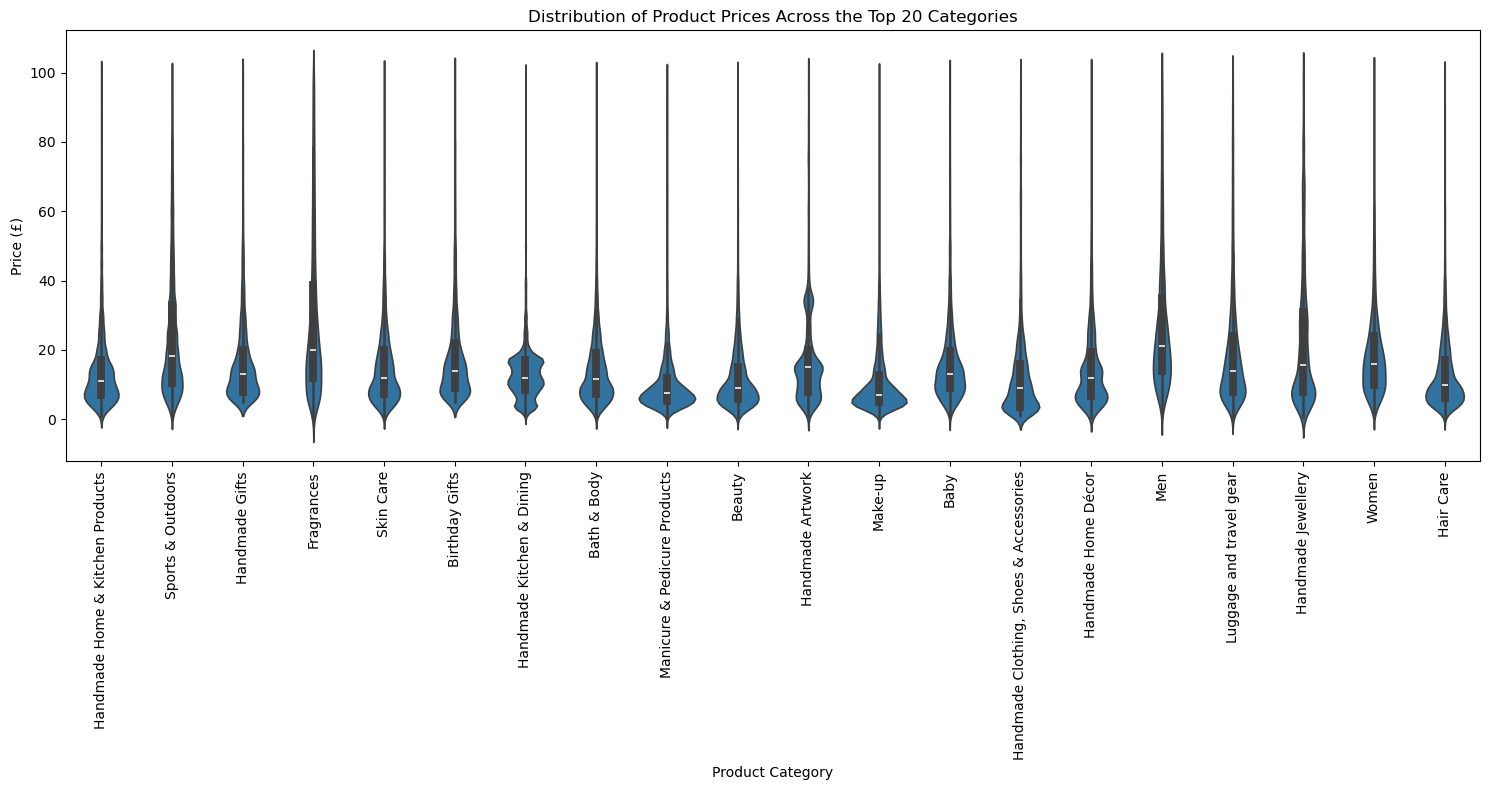

In [49]:
plt.figure(figsize=(15, 8))

sns.violinplot(
    data = df_top20,
    x = "category",
    y = "price")

plt.title("Distribution of Product Prices Across the Top 20 Categories")
plt.xlabel("Product Category")
plt.ylabel("Price (£)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [50]:
median_price_category = (
    df_no_outliers
    .groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

median_price_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

The highest median prices are within the Desktop PCs, Boxing Shoes and Tablets. 

In [51]:
top10_categories = df_no_outliers["category"].value_counts().head(10).index

In [52]:
df_top10 = df_no_outliers[df_no_outliers["category"].isin(top10_categories)]

In [54]:
avg_price = (df_top10
             .groupby("category")["price"]
             .mean()
             .sort_values(ascending=False))
avg_price

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

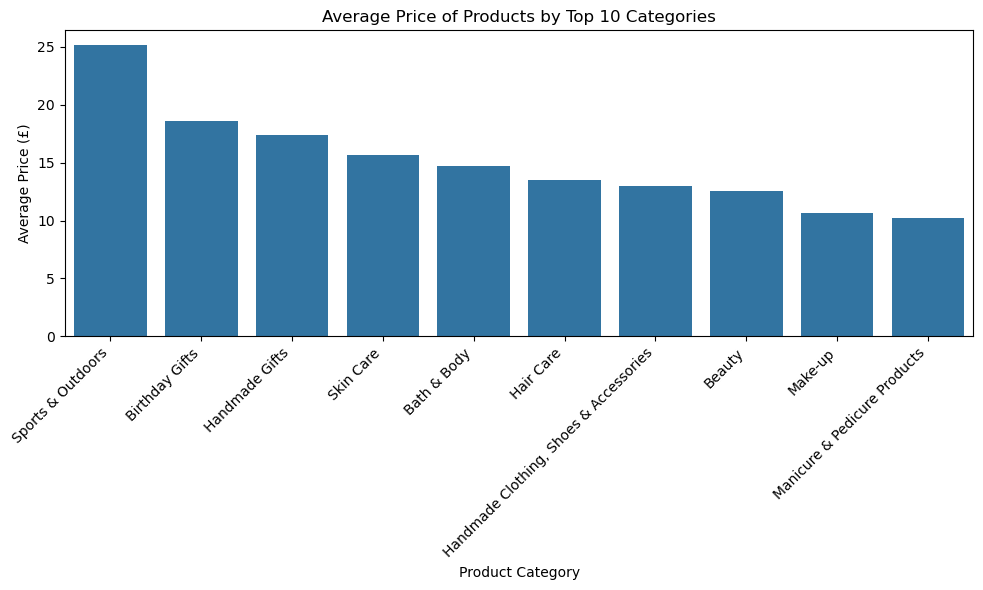

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price.index,
    y=avg_price.values
)

plt.title("Average Price of Products by Top 10 Categories")
plt.xlabel("Product Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [56]:
avg_price_all = (
    df_no_outliers
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_all.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

Motherboards is the category with the highest average prices within its products.

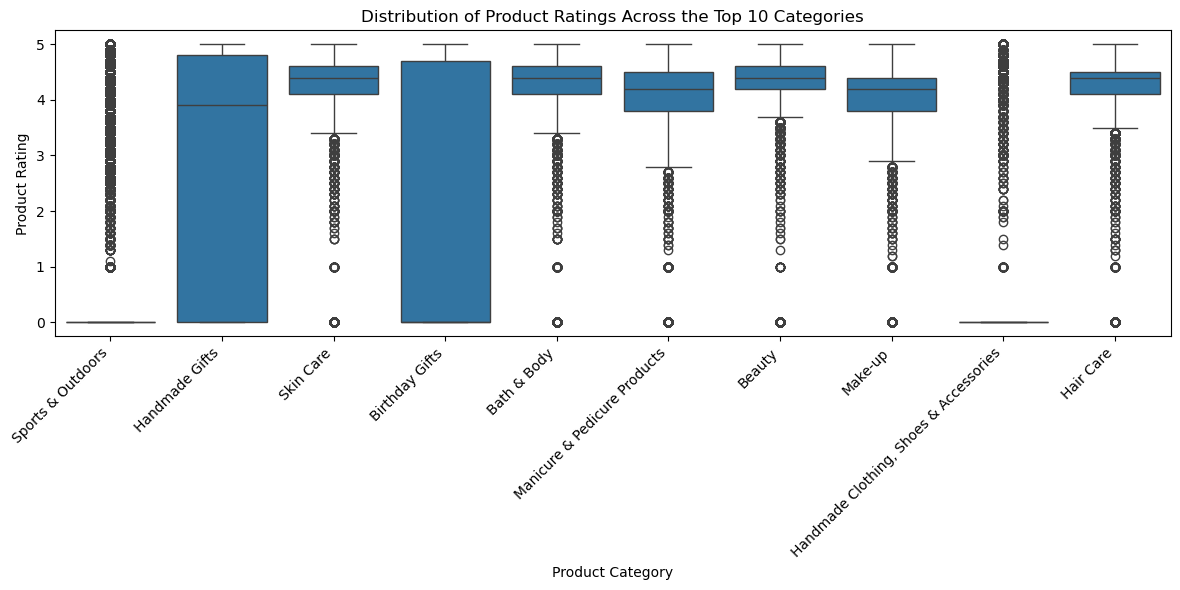

In [57]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top10,
    x="category",
    y="stars"
)

plt.title("Distribution of Product Ratings Across the Top 10 Categories")
plt.xlabel("Product Category")
plt.ylabel("Product Rating")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [58]:
median_rating = (
    df_no_outliers
    .groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

median_rating.head(10)

category
Computer Memory                 4.7
Beer, Wine & Spirits            4.6
Building & Construction Toys    4.6
Office Paper Products           4.6
Kids' Play Figures              4.6
Laptop Accessories              4.6
Hobbies                         4.6
Luxury Food & Drink             4.6
Soft Toys                       4.5
Boxes & Organisers              4.5
Name: stars, dtype: float64

Computer Memory has the highest median rating across all product categories.

### Part 3: Investigating the Interplay Between Product Prices and Ratings
#### Objective: Analyze how product ratings (stars) correlate with product prices.

Correlation Coefficients:
- Calculate the correlation coefficient between price and stars.
- Is there a significant correlation between product price and its rating?

Visualizations:
- Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
- Use a correlation heatmap to visualize correlations between all numerical variables.

In [60]:
#correlation coefficients:
correlation = df_no_outliers["price"].corr(df_no_outliers["stars"])

print(correlation)

-0.07767299878181352


The correlation between price and rating is negative, meaning that as the price inscreases, the rating tends to slightly decrease. The absolute value of 0.0777 indicates a very weak linear relationship.

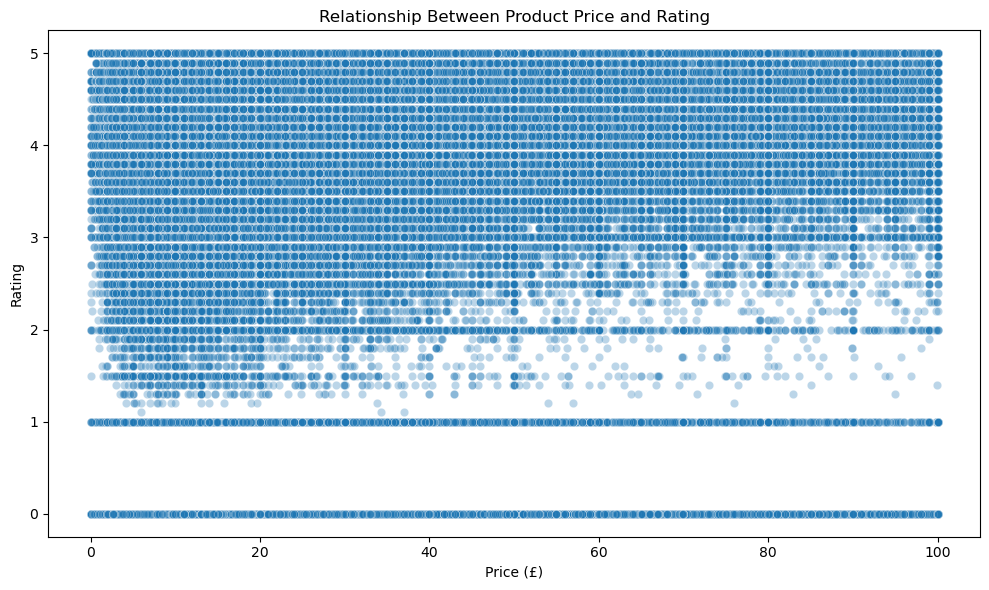

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_no_outliers,
    x="price",
    y="stars",
    alpha=0.3
)

plt.title("Relationship Between Product Price and Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

The scatter plot shows no clear upward or downward trend. Ratings are spread across nearly all price levels, suggesting that product price is not a strong predictor of customer ratings.

In [62]:
numerical = df_no_outliers.select_dtypes(include="number")

In [63]:
correlation_matrix = numerical.corr()

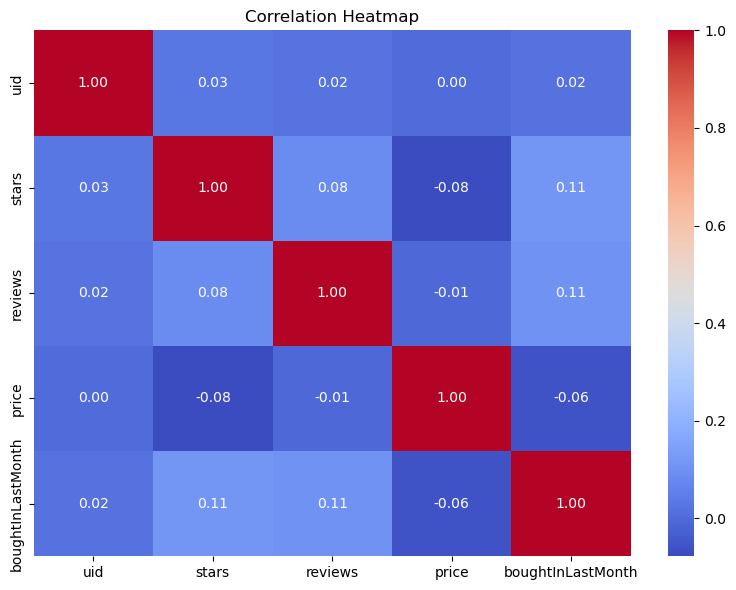

In [64]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

The analysis revealed a very weak correlation between product prices and customer ratings. The scatter plot and correlation heatmap suggest that expensive products are not necessarily associated with higher customer satisfaction. Therefore, pricing alone does not appear to be a strong driver of product ratings in this dataset.